# Tymoteusz Hanusiak

 - Sieć Neuronowa została napisana od scratcha 

#### Projekt zaliczeniowy - Sztuczne Sieci Neuronowe (problem klasyfikacyjny)



**Wykorzystywany dataset:**
 [Banknote Authentication](https://archive.ics.uci.edu/dataset/267/banknote+authentication)

 ______

#### Krótki wstęp

Dane uzyskano z obrazów, które wykonano w celu diagnostyki uwietrzylniania banknotów - przedstawiające zarówno prawdziwe, jak i podrobione sztuki:
- w procesie tym wykorzystano kamerę przemysłową stosowaną do kontroli druku,
- cechowały się one rozdzielczością 400x400 px i około 660 dpi (w skali szarości),
- cechy fotografii wyodrębniono dzięki [transformacji falkowej](https://pl.wikipedia.org/wiki/Transformacja_falkowa).

Dataset podzielono na zestaw **treningowy** jak i **testowy**.

Opis zmiennych:

| Zmienna | Rola            | Typ       | Opis                                             | Jednostki | Braki danych    |
|----------------|------------------|-----------|--------------------------------------------------|-----------|---------------|
| Wariancja         | Cecha     | Ciągła (float64)        | Wariancja obrazu po transformacji falkowej       | -     | Nie            |
| Skośność          | Cecha     | Ciągła  (float64)       | Skośność obrazu po transformacji falkowej        | -      | Nie           |
| Kurtoza           | Cecha     | Ciągła (float64)        | Kurtoza obrazu po transformacji falkowej         | -      | Nie           |
| Entropia          | Cecha     | Ciągła (float64)        | Entropia obrazu (miara losowości)                | -      | Nie           |
| Klasa             | Cel       | Całkowita  (int64)     | Klasa: 0 = prawdziwy, 1 = fałszywy               | -      | Nie           |


W celu klasfyikacji klasy banknotu zaprogramowano sztuczną sieć neuronową. W ramach analizy porównano wydajność 5 funkcji aktywacji w warstwie ukrytej:
- sigmoidę,
- tangens hiperboliczny,
- ReLU,
- leaky ReLU,
- funkcję liniową.

W warstwie output zastosowano funkcję `softmax`, a do oceny jakości modelu wykorzystano funkcję kosztu `cross-entropy` - mierzącą różnicę między wartościami teoretycznymi i empirycznymi. Wagi i biasy optymalizowano przy użyciu algorytmu `gradient descent`, a uczenie sieci przeprowadzono przez określoną ilość epok. Dla każdej kombinacji parametrów przeprowadzono kilka powtórzeń.
<br>

Ostateczne wyniki przedstawiono na wykresach ilustrujących zależność średniej dokładności (accuracy) od:
- liczby neuronów w warstwie ukrytej,
- współczynnika uczenia,
- typu funkcji aktywacji,
- wielkości zbioru testowego,
- liczby epok.

#### Projektowanie sieci

Import bibliotek:

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import itertools
import matplotlib.pyplot as plt

Programowanie klasy NeuralNetwork

In [24]:
class NeuralNetwork:
    @staticmethod
    def _sigmoid(z):
        return 1 / (1 + np.exp(-z))

    @staticmethod
    def _sigmoid_prime(z):
        s = NeuralNetwork._sigmoid(z)
        return s * (1 - s)

    @staticmethod
    def _tanh(z):
        return np.tanh(z)

    @staticmethod
    def _tanh_prime(z):
        return 1 - np.tanh(z) ** 2

    @staticmethod
    def _relu(z):
        return np.maximum(0, z)

    @staticmethod
    def _relu_prime(z):
        return (z > 0).astype(float)

    @staticmethod
    def _leaky_relu(z, alpha: float = 0.01):
        return np.where(z > 0, z, alpha * z)

    @staticmethod
    def _leaky_relu_prime(z, alpha: float = 0.01):
        return np.where(z > 0, 1.0, alpha)

    @staticmethod
    def _linear(z):
        return z

    @staticmethod
    def _linear_prime(z):
        return np.ones_like(z)

    # inicjalizacja
    def __init__(
        self,
        x: np.ndarray,
        y: np.ndarray,
        hidden_size: int = 16,
        lr: float = 0.01,
        activation: str = "sigmoid",
    ) -> None:

        self.X = x.astype(float)
        self.y = y.astype(float)
        n_samples, n_features = self.X.shape
        n_classes = self.y.shape[1]

        rng = np.random.default_rng()
        self.W1 = rng.normal(0, 1.0 / np.sqrt(n_features), (n_features, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = rng.normal(0, 1.0 / np.sqrt(hidden_size), (hidden_size, n_classes))
        self.b2 = np.zeros((1, n_classes))

        self.lr = lr
        self.set_activation(activation)

    # ustawianie aktywacji 
    def set_activation(self, name: str):
        funcs = {
            "sigmoid": (self._sigmoid, self._sigmoid_prime),
            "tanh": (self._tanh, self._tanh_prime),
            "relu": (self._relu, self._relu_prime),
            "leaky_relu": (self._leaky_relu, self._leaky_relu_prime),
            "linear": (self._linear, self._linear_prime),
        }
        if name not in funcs:
            raise ValueError(f"Nieznana funkcja aktywacji: {name}")
        self.activation, self.activation_prime = funcs[name]

    # softmax i cross‑entropy
    @staticmethod
    def _softmax(z: np.ndarray) -> np.ndarray:
        e = np.exp(z - np.max(z, axis=1, keepdims=True))
        return e / np.sum(e, axis=1, keepdims=True)

    @staticmethod
    def _cross_entropy(y_true: np.ndarray, y_pred: np.ndarray) -> float:
        eps = 1e-9
        return -np.mean(np.sum(y_true * np.log(y_pred + eps), axis=1))

    # trening 
    def train(self, epochs: int = 1000, x_val: np.ndarray | None = None, y_val: np.ndarray | None = None):
        self.history = {"epoch": [], "train_acc": []}
        if x_val is not None:
            self.history["val_acc"] = []

        for ep in range(1, epochs + 1):
            # forward
            z1 = self.X @ self.W1 + self.b1
            a1 = self.activation(z1)
            z2 = a1 @ self.W2 + self.b2
            a2 = self._softmax(z2)

            # backward
            dz2 = a2 - self.y
            dW2 = a1.T @ dz2 / len(self.X)
            db2 = dz2.mean(axis=0, keepdims=True)

            da1 = dz2 @ self.W2.T
            dz1 = da1 * self.activation_prime(z1)
            dW1 = self.X.T @ dz1 / len(self.X)
            db1 = dz1.mean(axis=0, keepdims=True)

            # update
            self.W2 -= self.lr * dW2
            self.b2 -= self.lr * db2
            self.W1 -= self.lr * dW1
            self.b1 -= self.lr * db1

            # historia
            self.history["epoch"].append(ep)
            self.history["train_acc"].append(self.accuracy(self.X, self.y))
            if x_val is not None:
                self.history["val_acc"].append(self.accuracy(x_val, y_val))

    # predykcja
    def predict(self, x: np.ndarray) -> np.ndarray:
        z1 = x @ self.W1 + self.b1
        a1 = self.activation(z1)
        z2 = a1 @ self.W2 + self.b2
        a2 = self._softmax(z2)
        return np.argmax(a2, axis=1)

    def accuracy(self, x: np.ndarray, y_true: np.ndarray) -> float:
        preds = self.predict(x)
        labels = np.argmax(y_true, axis=1)
        return np.mean(preds == labels)

Przykładowe zastosowanie:

In [25]:
if __name__ == "__main__":
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
    df = pd.read_csv(url, header=None)
    X = df.iloc[:, :-1].values.astype(float)
    y_raw = df.iloc[:, -1].values.astype(int)
    y = np.eye(2)[y_raw]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    nn = NeuralNetwork(X_train, y_train, hidden_size=12, lr=0.01, activation="relu")
    nn.train(epochs=500, x_val=X_test, y_val=y_test)
    print("Test accuracy:", nn.accuracy(X_test, y_test))

    sample = np.array([[0, 0, 0, 0]])
    pred = nn.predict(sample)
    print("Klasa:", int(pred))

Test accuracy: 0.9709090909090909
Klasa: 1


Przeprowadzenie symulacji i zebranie wyników do pliku `results_banknote.csv`:

In [26]:
URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
df = pd.read_csv(URL, header=None)
X = df.iloc[:, :-1].values.astype(float)
y = np.eye(2)[df.iloc[:, -1].values.astype(int)] # one-hot

# parametry
hidden_sizes = [4, 8, 16, 32, 64]
lrs = [1.0, 0.1, 0.01, 0.001]
activations = ["sigmoid", "tanh", "relu", "leaky_relu"]
test_sizes = [0.2, 0.3, 0.4, 0.5]
epochs_list  = [100, 200, 300, 400]
REPEATS = 5

records = []

for hs, lr, act, ts, ep in itertools.product(
        hidden_sizes, lrs, activations, test_sizes, epochs_list):
    for seed in range(REPEATS):
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=ts, random_state=seed, shuffle=True
        )
        net = NeuralNetwork(
            X_tr, y_tr,
            hidden_size=hs, lr=lr, activation=act
        )
        net.train(epochs=ep) 
        records.append(dict(
            hidden_size=hs, lr=lr, activation=act, test_size=ts,
            epochs=ep,
            train_acc=net.accuracy(X_tr, y_tr),
            test_acc= net.accuracy(X_te, y_te)
        ))

# zapis wyników
out = pd.DataFrame(records)
out.to_csv("results_banknote.csv", index=False)

def wykres(df, kolumna, etykieta):
    g = df.groupby(kolumna).agg(train=("train_acc", "mean"),
                                test=("test_acc",  "mean"))
    x  = g.index
    yt, yv = g["train"], g["test"]

    plt.figure(figsize=(6, 4))
    plt.plot(x, yt, marker="o", label="train")
    plt.plot(x, yv, marker="o", label="test")
    plt.xticks(x)
    plt.xlabel(etykieta)
    plt.ylabel("accuracy")
    plt.title(f"Średnia accuracy vs {etykieta}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

#### Podsumowanie i wnioski

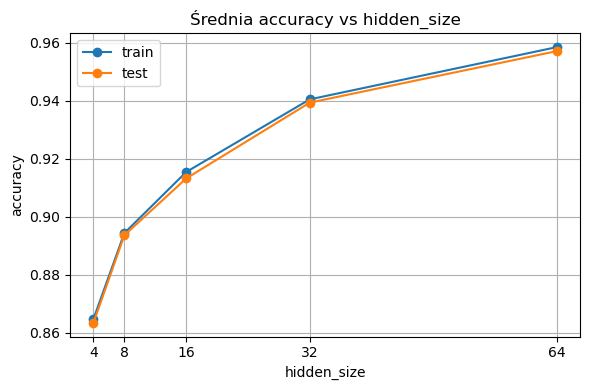

In [27]:
wykres(out, "hidden_size", "hidden_size")

Zwiększenie liczby neuronów w warstwie ukrytej skutkuje wzrostem dokładności klasyfikacji, zarówno na zbiorze treningowym, jak i testowym (bez oznak przeuczenia).

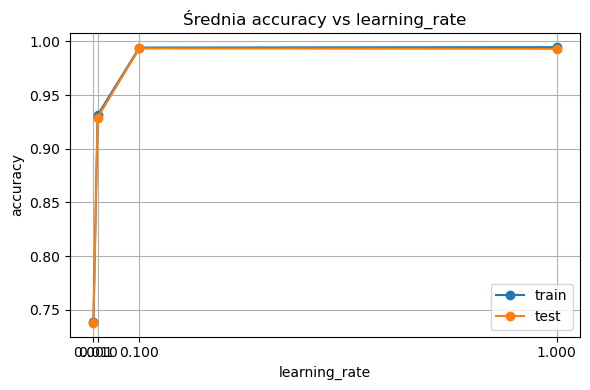

In [28]:
wykres(out, "lr", "learning_rate")

Wartości 0.1 i 1.0 pozwalają szybko osiągnąć wysoką dokładność.

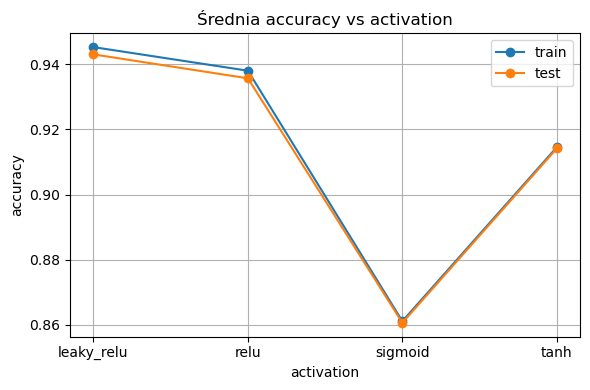

In [29]:
wykres(out, "activation", "activation")

Najmniej dokładną funkcją aktywacji jest sigmoida, a najbardziej - leaky ReLU.

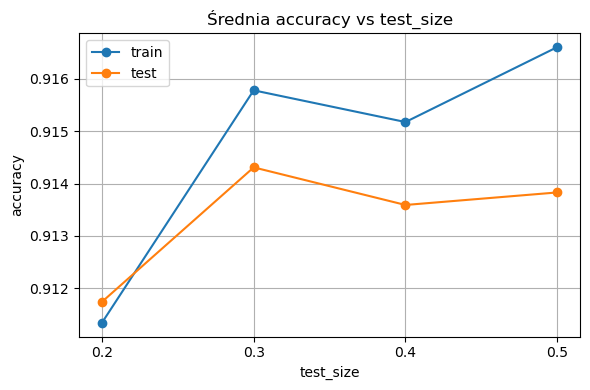

In [30]:
wykres(out, "test_size", "test_size")

Dokładność modelu pozostaje stabilna niezależnie od wielkości zbioru testowego.

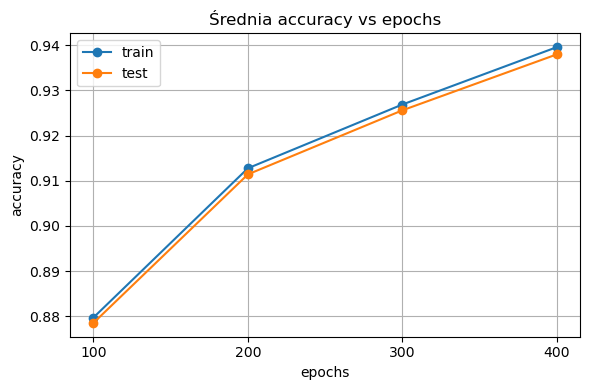

In [31]:
wykres(out, "epochs", "epochs")

Większa liczba epok systematycznie poprawia dokładność modelu zarówno na zbiorze treningowym, jak i testowym.

________________

#### Publikacje naukowe

- https://www.researchgate.net/profile/A-Shibghatullah/publication/279205560_BANKNOTE_AUTHENTICATION_USING_ARTIFICIAL_NEURAL_NETWORK/links/559dd30f08ae04e365090037/BANKNOTE-AUTHENTICATION-USING-ARTIFICIAL-NEURAL-NETWORK.pdf
- https://www.researchgate.net/profile/Priya-R-L-2/publication/323223299_Analysis_of_Banknote_Authentication_System_using_Machine_Learning_Techniques/links/60e03189299bf1ea9edb3cf7/Analysis-of-Banknote-Authentication-System-using-Machine-Learning-Techniques.pdf
- https://www.sciencedirect.com/science/article/pii/S1532046403000340